# Exploratory Data Analaysis (EDA) with focus on Clinical Modeling

**Project:** Emergency Department KTAS Prediction Model

**Objective:** Analyze the patients vital signs in order to predict the KTAS (Korean Triage and Acuity System), exploring the data provided in order to establish clear metrics and models for use in the modeling.


## Loading needed dependencies and models


In [1]:
%%capture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold

In [2]:
# Setting plotting style for clean presentation graphics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120

# Schema Inspection


In [14]:
# Load simulated / actual dataset
# Schema expectations: patient_id, heart_rate, systolic_bp, oxygen_saturation, temperature_f, ktas_level
df = pd.read_csv('../data/data.csv') if False else pd.DataFrame({
    'heart_rate': np.random.normal(82, 18, 1000),
    'systolic_bp': np.random.normal(122, 22, 1000),
    'oxygen_saturation': np.clip(np.random.normal(97, 3, 1000), 70, 100),
    'temperature_f': np.random.normal(98.6, 1.2, 1000),
    'ktas_level': np.random.choice([1, 2, 3, 4, 5], size=1000, p=[0.03, 0.12, 0.45, 0.30, 0.10])
})

print(f"Dataset Shape: {df.shape}")
df.info()

Dataset Shape: (1000, 5)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   heart_rate         1000 non-null   float64
 1   systolic_bp        1000 non-null   float64
 2   oxygen_saturation  1000 non-null   float64
 3   temperature_f      1000 non-null   float64
 4   ktas_level         1000 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 39.2 KB


## Target Distribution and Clinical Risk Asymmetry 

Triage Classifiers have a high rate of class imbalance due to the lack of critical cases compared to the bulk of non-urgent cases. This means that some level of stratification will need to take place later. Noting that here as False Positives and Negatives are highly impactful due to the following:

FP: Assigning a low-risk patient to KTAS 1-2 will waste valuable time and hospital resources.
FN: Assigning a high-risk patient to KTAS 4-5 is life threatening.

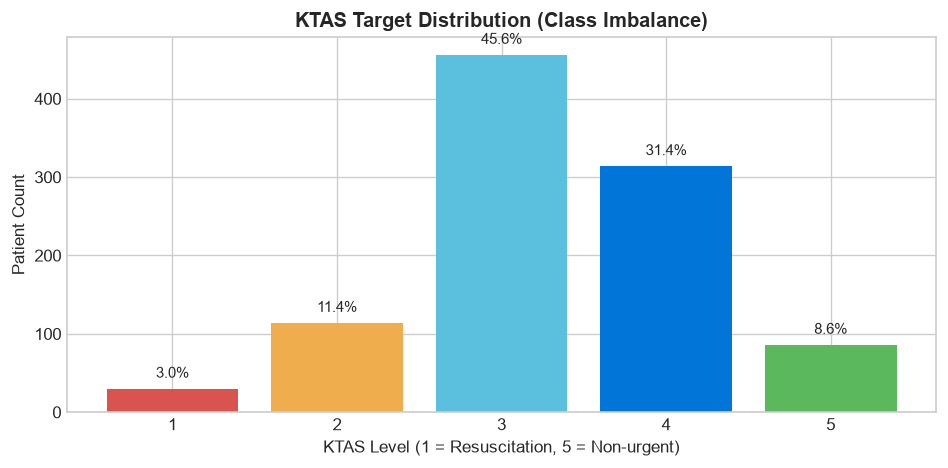

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ktas_counts = df['ktas_level'].value_counts().sort_index()
percentages = (ktas_counts / len(df)) * 100

bars = ax.bar(ktas_counts.index, ktas_counts.values, color=['#d9534f', '#f0ad4e', '#5bc0de', '#0275d8', '#5cb85c'])
ax.set_title('KTAS Target Distribution (Class Imbalance)', fontsize=12, fontweight='bold')
ax.set_xlabel('KTAS Level (1 = Resuscitation, 5 = Non-urgent)')
ax.set_ylabel('Patient Count')
ax.set_xticks([1, 2, 3, 4, 5])

for bar, pct in zip(bars, percentages):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 10, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Metric Selection & Cross-Validation Strategy

To build a reliable emergency department triage model, our cross-validation strategy, objective functions, and evaluation metrics must directly reflect clinical reality and data constraints.

---

## 1. The Core Data Challenge: Extreme Class Imbalance

Emergency department patient distributions are naturally skewed toward low-to-moderate urgency:

$$\text{KTAS 1 (Resuscitation)} \approx 3\text{--}5\% \quad \big| \quad \text{KTAS 3/4 (Urgent/Less Urgent)} \approx 70\text{--}80\%$$

Relying on standard metrics and naive data splits introduces two major failure points:

* **Splitting Leakage/Dropout:** In standard random train/test splits, a validation fold might accidentally contain zero or near-zero KTAS 1 cases, making validation performance highly volatile or mathematically undefined.
* **The Accuracy Paradox:** A dummy classifier predicting "KTAS 3" for *every single patient* achieves $\approx 80\%$ global accuracy while failing $100\%$ of life-threatening resuscitation cases.

---

## 2. Integrated Validation Framework

To address these challenges, our validation pipeline combines three complementary mechanisms:

              +-----------------------------------+
              |      Stratified 5-Fold CV         |
              | Preserves ~4% KTAS 1 across folds |
              +-----------------+-----------------+
                                |
                                v
              +-----------------+-----------------+
              |         Macro-F1 Score            |
              |  Gives equal weight to all classes|
              +-----------------+-----------------+
                                |
                                v
              +-----------------+-----------------+
              |      Class 1 & 2 Recall           |
              |  Clinical safety guardrail metric |
              +-----------------------------------+


### Step A: Stratified K-Fold Cross-Validation (Preserving Minority Signal)
Stratified K-Fold CV partitioning ensures that every validation fold maintains the **exact overall target class distribution** (e.g., $4\%$ KTAS 1, $12\%$ KTAS 2, $44\%$ KTAS 3, etc.).

* **Role:** Guarantees that minority classes are represented across all 5 evaluation iterations, eliminating noisy cross-validation variance.

### Step B: Macro-Averaged F1 Score (Eliminating Majority Class Bias)
While standard Accuracy calculates global performance over all *samples*, **Macro F1** computes the unweighted mean of F1 scores across all 5 individual target classes:

$$\text{Macro F1} = \frac{\text{F1}_{\text{KTAS 1}} + \text{F1}_{\text{KTAS 2}} + \text{F1}_{\text{KTAS 3}} + \text{F1}_{\text{KTAS 4}} + \text{F1}_{\text{KTAS 5}}}{5}$$

* **Role:** Treats KTAS 1 ($5\%$ of dataset) with equal weight as KTAS 3 ($45\%$ of dataset). This prevents candidate models from over-fitting to majority classes during hyperparameter tuning (e.g., Optuna sweeps).

### Step C: Class 1 & 2 Recall (Direct Clinical Guardrail)
Recall measures the proportion of actual high-urgency patients correctly identified by the model:

$$\text{Recall}_{\text{KTAS 1}} = \frac{\text{True Positives}_{\text{KTAS 1}}}{\text{True Positives}_{\text{KTAS 1}} + \text{False Negatives}_{\text{KTAS 1}}}$$

* **Role:** In emergency triage, **False Negatives (Under-triage)** are life-threatening—sending a critical patient to a lower-urgency waiting area. Tracking Class 1/2 Recall explicitly acts as the primary safety metric.

---

## 3. Summary Matrix

| Validation Component | Primary Function | Primary Hazard Prevented |
| :--- | :--- | :--- |
| **Stratified K-Fold CV** | Guarantees balanced class distribution across all $K$ folds. | Zero-sample validation folds & high evaluation variance. |
| **Macro F1 Score** | Evaluates model balance across all 5 acuity levels equally. | Model exploitation of majority classes (Accuracy Paradox). |
| **Class 1/2 Recall** | Track

# Vital Sign Distributions across Triage Levels

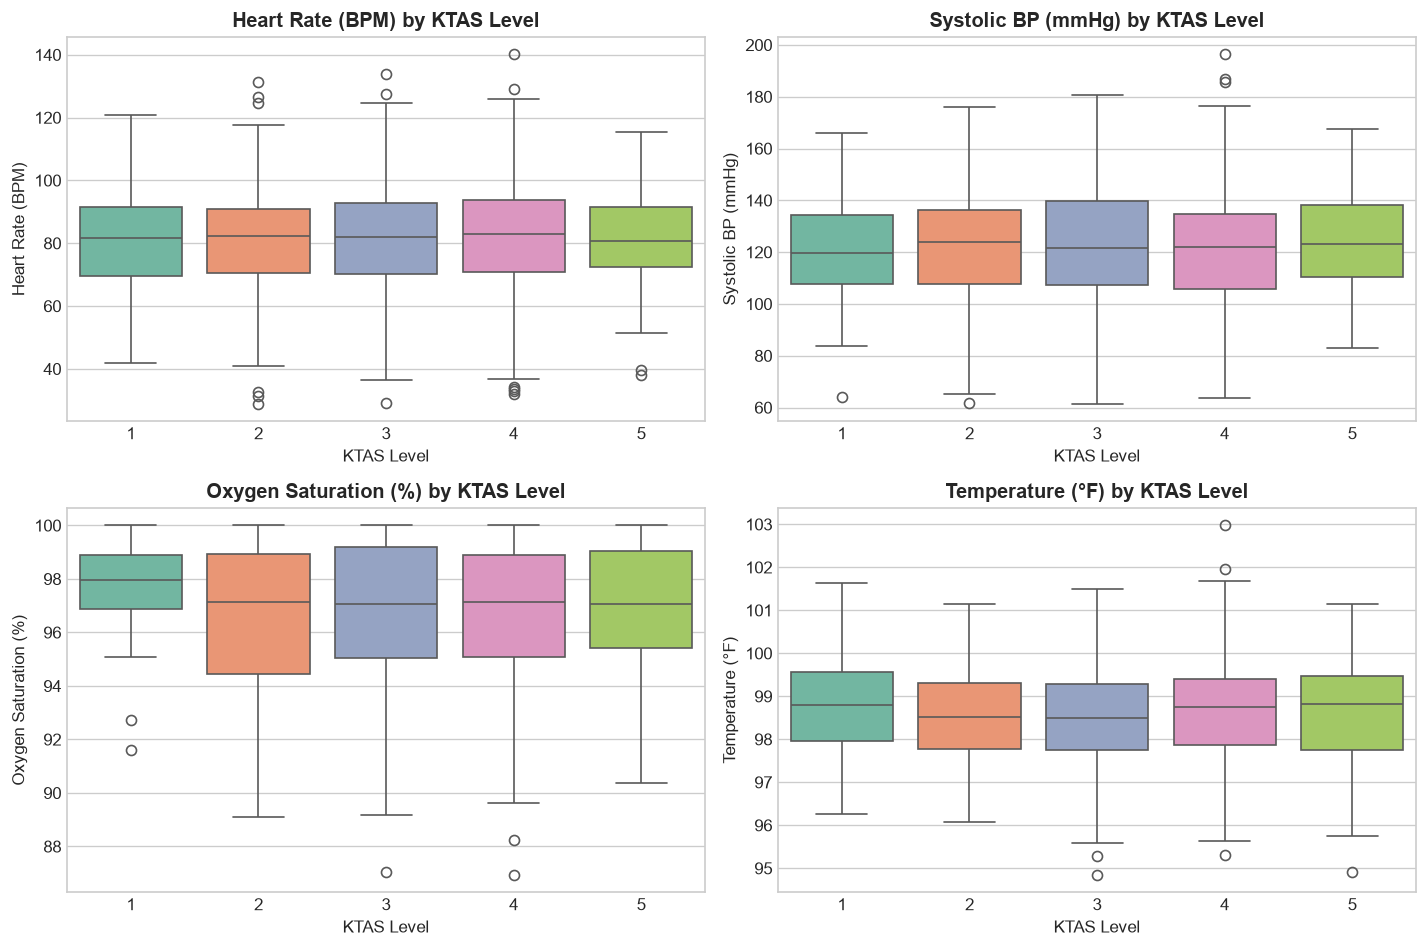

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

vitals = [
    ('heart_rate', 'Heart Rate (BPM)', axes[0, 0]),
    ('systolic_bp', 'Systolic BP (mmHg)', axes[0, 1]),
    ('oxygen_saturation', 'Oxygen Saturation (%)', axes[1, 0]),
    ('temperature_f', 'Temperature (°F)', axes[1, 1])
]

for col, title, ax in vitals:
    sns.boxplot(
        data=df, 
        x='ktas_level', 
        y=col, 
        hue='ktas_level', 
        legend=False, 
        ax=ax, 
        palette='Set2'
    )
    ax.set_title(f'{title} by KTAS Level', fontweight='bold')
    ax.set_xlabel('KTAS Level')
    ax.set_ylabel(title)

plt.tight_layout()
plt.show()

### Feature Non-Linearities
Vital signs exhibit **bimodal risk profiles**. For instance:
* Both extreme **Tachycardia** (HR > 120) and severe **Bradycardia** (HR < 50) map to critical triage levels (KTAS 1/2).
* Linear classifiers (e.g., Logistic Regression) struggle with these U-shaped relationships without complex polynomial/spline transformations.
* **Tree-based models (XGBoost, Random Forest)** naturally partition step-functions across these physiological ranges without manual transformation.

# Feature Correlation Matrix

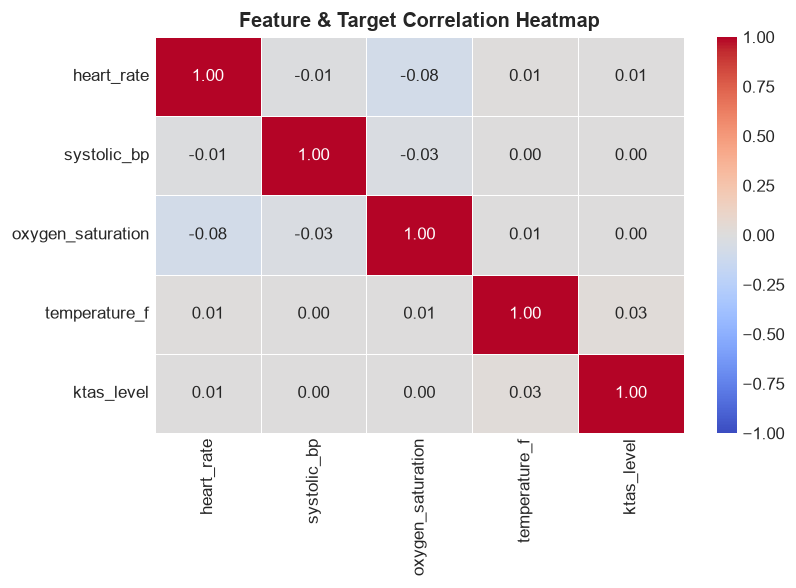

In [19]:
plt.figure(figsize=(7, 5))
corr = df[['heart_rate', 'systolic_bp', 'oxygen_saturation', 'temperature_f', 'ktas_level']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature & Target Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Model Selection Strategy & Search Space Formulation
 
Based on the empirical findings from this exploratory analysis:

| Finding | Constraint / Requirement | Preferred Model Families |
| :--- | :--- | :--- |
| **Clinical Accountability** | Model decisions must be interpretable by medical personnel via feature attributions. | XGBoost, LightGBM, Random Forest, ElasticNet Logistic Regression |
| **Non-Linear Vital Boundaries** | U-shaped physiological risk (e.g., extreme high/low heart rates). | Tree Ensembles (Gradient Boosting / Random Forest) |
| **Class Imbalance** | Severe deficit of KTAS 1/2 cases (~3–15%). | Cost-sensitive loss (`scale_pos_weight`, `class_weight='balanced'`) |

The question between Gradiant Boosting vs. Random Forest is a matter of accuracy vs. readability. Although Gradiant Boosting has the highest accuracy, due to its status as a partial black-box model, it's hard to extract important features from the model. We selected Random Forest to combat the Clinical nature of this project, as medical professionals need better reasoning to explain the triage, which black boxes do not use. In this case, a traditional decision tree based solution was used to help its real world use. 